In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
from sklearn import datasets

#### 1.生成模拟数据

In [19]:
X,y = datasets.load_diabetes(return_X_y=True)

In [20]:
X = X[:, 0].reshape(-1, 1)

In [21]:
true_w1=2
true_w2=1
true_b=3

In [22]:
y=true_w1*X+true_w2*(X**2)+true_b+np.random.randn(len(X),1)*1.5
#y=true_w*X+true_b+np.random.randn(len(X),1)*1.5

#### 2.初始化参数

In [32]:
w1 = np.random.randn(1)

In [33]:
w2 = np.random.randn(1)

In [34]:
b = np.random.randn(1)

In [35]:
learning_rate = 0.01

In [36]:
epochs = 2000

#### 3. 梯度下降

In [37]:
w1_history,w2_history,b_history,loss_history = [],[],[]

In [38]:
losses = []

In [40]:
for epoch in range(epochs):   
    
    ## 前向：计算预测值
    y_pred = w1*X+w2*(X**2)+b 
    
    ## 损失（均方误差） 
    loss = np.mean((y_pred-y)**2)
    losses.append(loss)

    ## 记录当前状态
    w1_history.append(w.copy())
    w2_history.append(w.copy())
    b_history.append(b.copy())
    loss_history.append(loss) 
    
    ## 梯度
    grad_w1 = np.mean(2*(y_pred-y)*X)
    grad_w2 = np.mean(2*(y_pred-y)*(X**2))
    grad_b = np.mean(2*(y_pred-y))
    
    ## 更新参数
    w1 -= learning_rate*grad_w1
    w2 -= learning_rate*grad_w2
    b -= learning_rate*grad_b
print(f"真实参数: w1={true_w1}, w2={true_w2},b={true_b}")
print(f"学到的参数: w1={w1[0]:.4f},w2={w2[0]:.4f}, b={b[0]:.4f}")

真实参数: w1=2, w2=1,b=3
学到的参数: w1=0.6095,w2=0.6208, b=3.0216


## 画图 

Text(0, 0.5, 'MSE Loss')

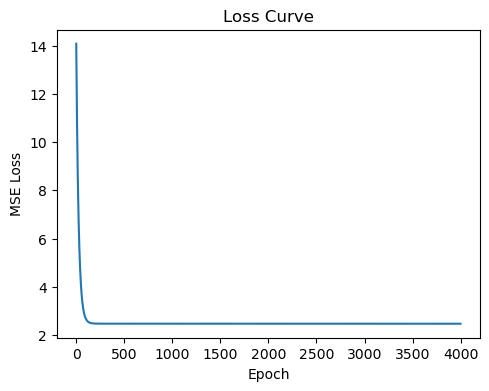

In [41]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

/Users/qnl315/miniconda3/envs/py3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/qnl315/miniconda3/envs/py3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/qnl315/miniconda3/envs/py3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/qnl315/miniconda3/envs/py3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/qnl315/miniconda3/envs/py3.10/lib/python3.10/site-packages/IPytho

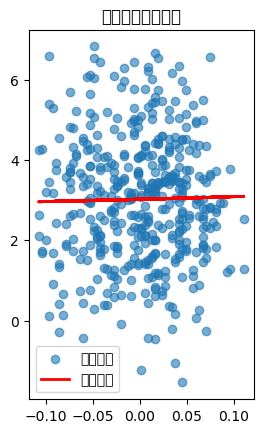

In [42]:
plt.subplot(1,2,2)
plt.scatter(X, y, alpha=0.6, label='真实数据')
plt.plot(X, w1*X+w2*(X**2)+b, 'r', linewidth=2, label='拟合直线')
plt.legend()
plt.title('线性回归拟合结果')
plt.show()

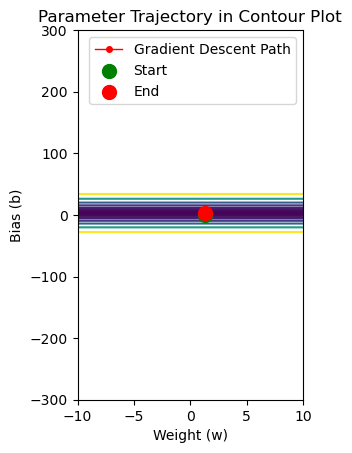

In [43]:
# 生成参数网格并计算损失值
W_grid, B_grid = np.meshgrid(np.linspace(-10, 10, 100), np.linspace(-300, 300, 100))
Z_grid = np.array([np.mean((w_ * X + b_ - y) ** 2) for w_, b_ in zip(np.ravel(W_grid), np.ravel(B_grid))])
Z_grid = Z_grid.reshape(W_grid.shape)

# 绘制等高线图
plt.subplot(1, 2, 2)
plt.contour(W_grid, B_grid, Z_grid, levels=np.logspace(-2, 3, 20), cmap='viridis')
plt.plot(w_history, b_history, 'r.-', markersize=8, linewidth=1, label='Gradient Descent Path')
plt.scatter(w_history[0], b_history[0], c='green', s=100, label='Start', zorder=5)
plt.scatter(w_history[-1], b_history[-1], c='red', s=100, label='End', zorder=5)
plt.title('Parameter Trajectory in Contour Plot')
plt.xlabel('Weight (w)')
plt.ylabel('Bias (b)')
plt.legend()
plt.show()